# Intelligent AOM: Simple Reproduction

Run this notebook from top to bottom. `QUICK_RUN = True` keeps the experiments small enough for CPU use; set it to `False` for larger report-style runs.

In [6]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42
QUICK_RUN = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True})
print('device:', DEVICE)

device: cuda


## AOM Simulator

In [7]:
DT, L = 1e-3, int(1e5)
F0, DFM, NM = 100.0, 0.1, 200

t = np.arange(L) * DT
f = np.arange(L // 2) * (1 / DT / L)
fm = F0 + np.arange(-NM // 2, NM // 2 + 1) * DFM
awg_freqs = np.arange(95.0, 106.0, 1.0)
out_freqs = np.arange(50.0, 151.0, 1.0)
awg_idx = (NM // 2 + np.rint((awg_freqs - F0) / DFM)).astype(int)
out_bins = np.rint(out_freqs / (1 / DT / L)).astype(int)

COS = np.cos(2 * np.pi * fm[awg_idx, None] * t)
SIN = np.sin(2 * np.pi * fm[awg_idx, None] * t)

def sample_awg(n, norm=0.1):
    y = np.random.normal(size=(n, 22)).astype(np.float32)
    y /= np.linalg.norm(y, axis=1, keepdims=True)
    return norm * y

def simulate_awg(x, response='sin'):
    am = x[:11] @ COS - x[11:] @ SIN
    rf = np.sin(2 * np.pi * am) if response == 'sin' else am ** 2
    spectrum = np.fft.fft(rf) / (L / 2)
    features = np.r_[spectrum[out_bins].real, spectrum[out_bins].imag].astype(np.float32)
    return am, rf, spectrum[:L // 2], features

def make_dataset(n, norm=0.1, response='sin'):
    y = sample_awg(n, norm)
    X = np.array([simulate_awg(row, response)[3] for row in y], dtype=np.float32)
    return X, y

print(f'AWG target: {len(awg_freqs)} complex tones = 22 values')
print(f'AOM feature: {len(out_freqs)} complex tones = 202 values')

AWG target: 11 complex tones = 22 values
AOM feature: 101 complex tones = 202 values


## Training Helper

In [8]:
def build_model(hidden=(1024, 128, 64)):
    layers = []
    last = 202
    for width in hidden:
        layers += [nn.Linear(last, width), nn.BatchNorm1d(width), nn.LeakyReLU()]
        last = width
    layers.append(nn.Linear(last, 22))
    return nn.Sequential(*layers)

def train_model(X, y, hidden=(1024, 128, 64), epochs=12, loss='mae'):
    data = TensorDataset(torch.tensor(X), torch.tensor(y))
    n_val = max(1, len(data) // 5)
    train_ds, val_ds = random_split(data, [len(data) - n_val, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256)

    model = build_model(hidden).to(DEVICE)
    criterion = nn.L1Loss() if loss == 'mae' else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train': [], 'val': []}

    for _ in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            batch_loss = criterion(model(xb), yb)
            batch_loss.backward()
            optimizer.step()
            train_loss += batch_loss.item() * len(xb)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += criterion(model(xb), yb).item() * len(xb)

        history['train'].append(train_loss / len(train_ds))
        history['val'].append(val_loss / len(val_ds))

    return model, history

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()

## Figure III.1: Target and Predicted AWG Spectrum

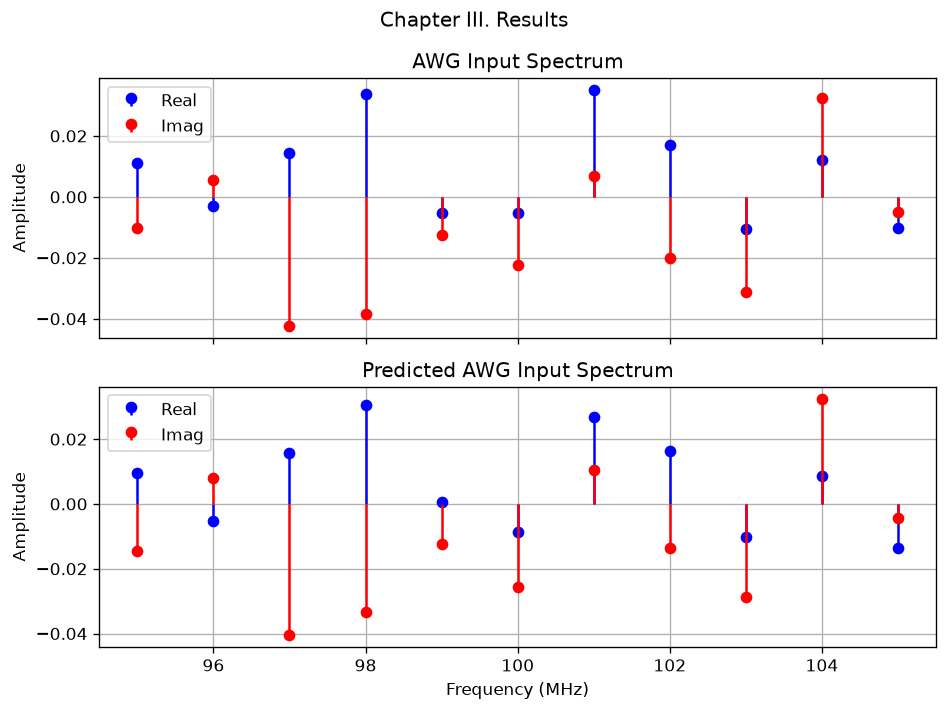

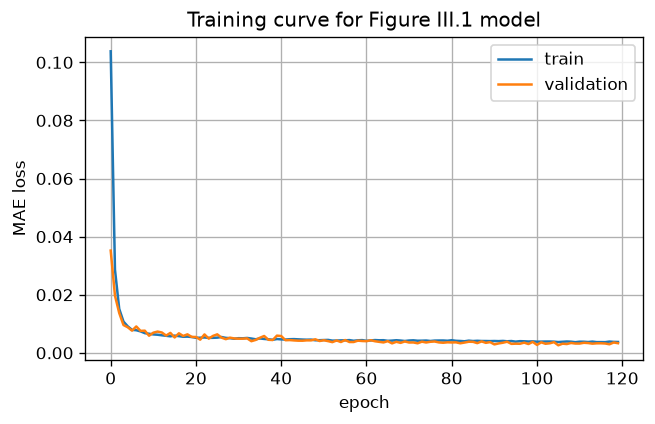

In [9]:
X, y = make_dataset(400 if QUICK_RUN else 10000, norm=0.1)
model, history = train_model(X, y, epochs=12 if QUICK_RUN else 120)
target = y[0]
pred = predict(model, X[:1])[0]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for ax, values, title in [
    (axes[0], target, 'AWG Input Spectrum'),
    (axes[1], pred, 'Predicted AWG Input Spectrum'),
]:
    ax.stem(awg_freqs, values[:11], linefmt='b-', markerfmt='bo', basefmt=' ', label='Real')
    ax.stem(awg_freqs, values[11:], linefmt='r-', markerfmt='ro', basefmt=' ', label='Imag')
    ax.set_title(title)
    ax.set_ylabel('Amplitude')
    ax.legend()

axes[1].set_xlabel('Frequency (MHz)')
fig.suptitle('Chapter III. Results')
fig.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.title('Training curve for Figure III.1 model')
plt.xlabel('epoch')
plt.ylabel('MAE loss')
plt.legend()
plt.show()

## Figure III.2: Loss vs Dataset Size at Different Input Norms

norm=0.1, samples=1000
norm=0.1, samples=5000
norm=0.1, samples=10000
norm=0.2, samples=1000
norm=0.2, samples=5000
norm=0.2, samples=10000
norm=0.3, samples=1000
norm=0.3, samples=5000
norm=0.3, samples=10000
norm=0.4, samples=1000
norm=0.4, samples=5000
norm=0.4, samples=10000


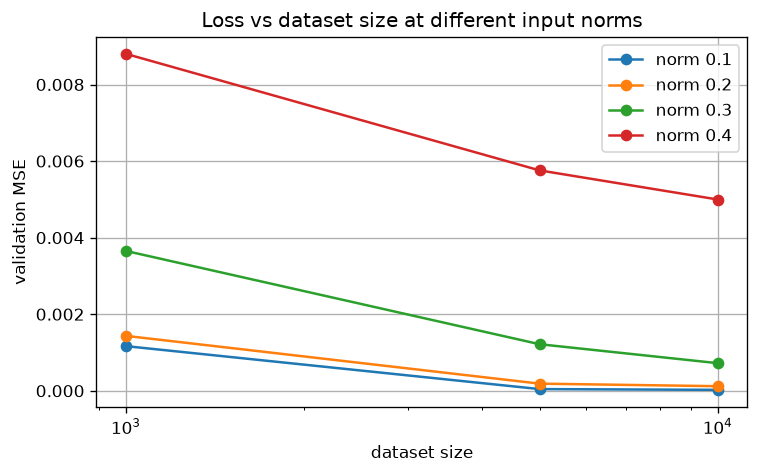

In [10]:
norms = [0.1, 0.2, 0.3, 0.4]
sizes = [200, 500, 1000] if QUICK_RUN else [1000, 5000, 10000]
epochs = 8 if QUICK_RUN else 80

losses = {norm: [] for norm in norms}
for norm in norms:
    for size in sizes:
        print(f'norm={norm}, samples={size}')
        Xn, yn = make_dataset(size, norm=norm)
        _, hist = train_model(Xn, yn, epochs=epochs, loss='mse')
        losses[norm].append(hist['val'][-1])

plt.figure(figsize=(7, 4))
for norm, vals in losses.items():
    plt.plot(sizes, vals, 'o-', label=f'norm {norm}')
plt.xscale('log')
plt.title('Loss vs dataset size at different input norms')
plt.xlabel('dataset size')
plt.ylabel('validation MSE')
plt.legend()
plt.show()

## Figure III.3: Loss vs Layer Size

first hidden layer width=64
first hidden layer width=128
first hidden layer width=256
first hidden layer width=512
first hidden layer width=1024
first hidden layer width=2048
first hidden layer width=4096
first hidden layer width=8192
first hidden layer width=16384


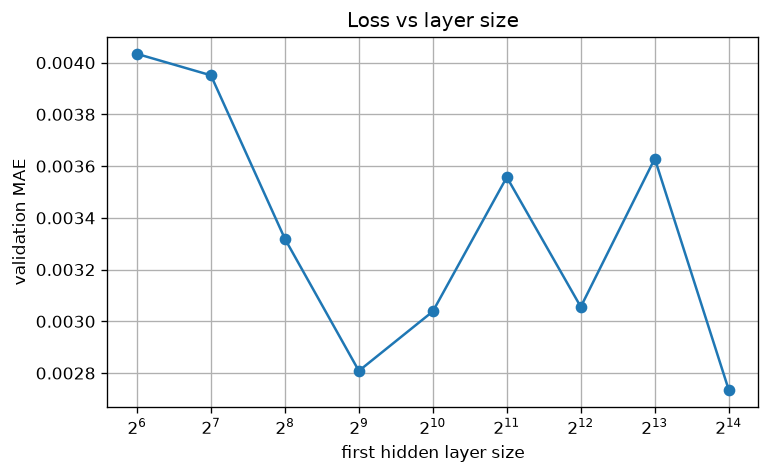

In [11]:
widths = [64, 128, 256, 512, 1024] if QUICK_RUN else [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16_384]
X_layer, y_layer = make_dataset(500 if QUICK_RUN else 10_000, norm=0.1)

layer_losses = []
for width in widths:
    print(f'first hidden layer width={width}')
    _, hist = train_model(X_layer, y_layer, hidden=(width, 128, 64), epochs=8 if QUICK_RUN else 80)
    layer_losses.append(hist['val'][-1])

plt.figure(figsize=(7, 4))
plt.plot(widths, layer_losses, 'o-')
plt.xscale('log', base=2)
plt.title('Loss vs layer size')
plt.xlabel('first hidden layer size')
plt.ylabel('validation MAE')
plt.show()

## Double-Pass Outlook Model

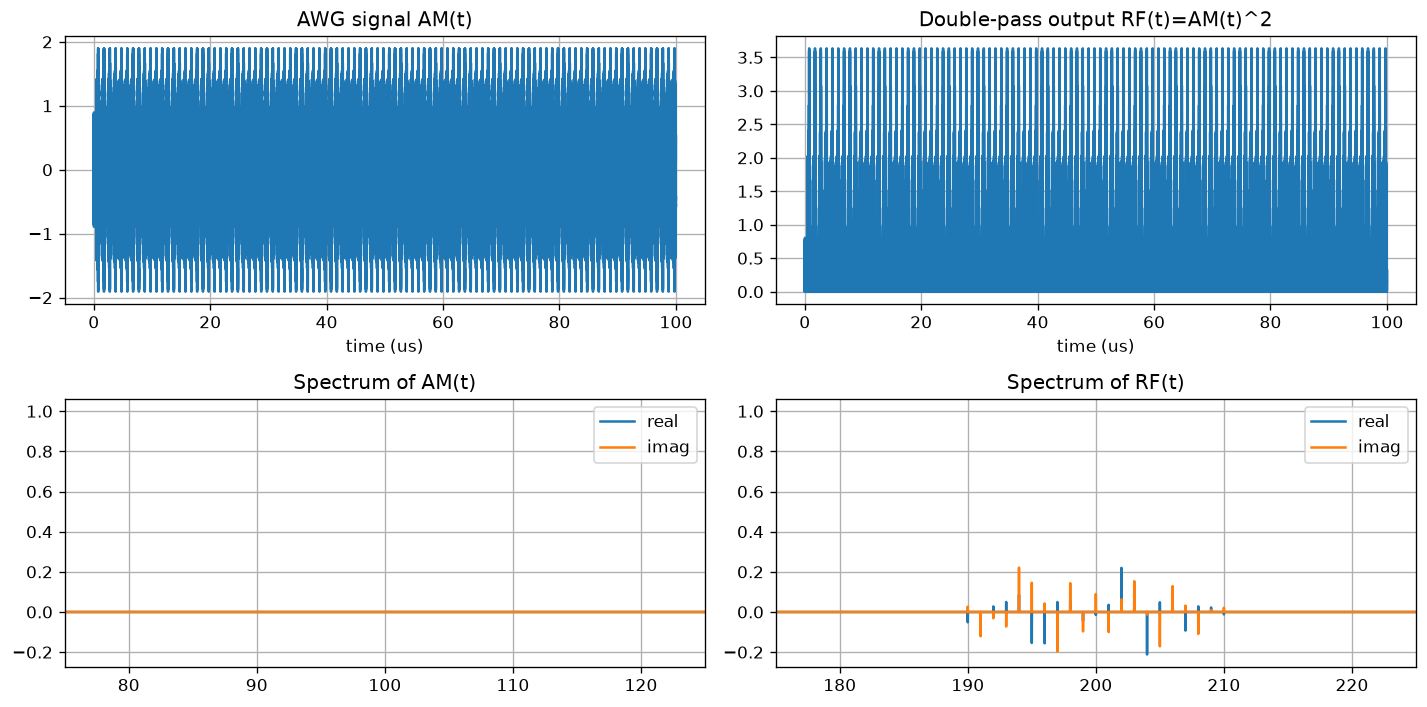

In [12]:
x = sample_awg(1, norm=1.0)[0]
AM, RF, spectrum_AM, _ = simulate_awg(x, response='double_pass')
spectrum_RF = np.fft.fft(RF)[:L // 2] / (L / 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].plot(t, AM)
axes[0, 0].set_title('AWG signal AM(t)')
axes[0, 0].set_xlabel('time (us)')

axes[0, 1].plot(t, RF)
axes[0, 1].set_title('Double-pass output RF(t)=AM(t)^2')
axes[0, 1].set_xlabel('time (us)')

axes[1, 0].plot(f, spectrum_AM.real, label='real')
axes[1, 0].plot(f, spectrum_AM.imag, label='imag')
axes[1, 0].set_xlim(75, 125)
axes[1, 0].set_title('Spectrum of AM(t)')
axes[1, 0].legend()

axes[1, 1].plot(f, spectrum_RF.real, label='real')
axes[1, 1].plot(f, spectrum_RF.imag, label='imag')
axes[1, 1].set_xlim(175, 225)
axes[1, 1].set_title('Spectrum of RF(t)')
axes[1, 1].legend()

fig.tight_layout()
plt.show()